In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np


In [20]:
def draw_bar(ax, file_path, key,q=0.8, ):

    with open(file_path, 'r') as f:
        data = json.load(f)

    bins = np.array(data['bins'], dtype=float)      # N+1
    chosen = np.array(data[key], dtype=int)    # N

    idx = (bins[1:] + bins[:-1]) / 2
    widths = bins[1:] - bins[:-1]

    # ===== 80% rank =====
    total = chosen.sum()
    r = int(np.ceil(q * total))

    cum = np.cumsum(chosen)
    q_idx = int(np.searchsorted(cum, r, side="left"))

    cum_before = cum[q_idx - 1] if q_idx > 0 else 0
    offset = r - cum_before
    frac = (offset - 0.5) / chosen[q_idx]
    frac = np.clip(frac, 0.0, 1.0)

    q_entropy = bins[q_idx] + frac * (bins[q_idx + 1] - bins[q_idx])

    # ===== plot =====
    ax.set_yscale('log')
    ax.bar(idx, chosen, width=widths, edgecolor='black')
    ax.axvline(q_entropy, color='red', linestyle='--', linewidth=2,label=f"The {int(q*100)}th percentile = {q_entropy:.3f}")
    ax.legend(fontsize=9)
    ax.set_xlim(bins[0], bins[-1])
    ax.set_title(f"Epoch {file_path.split('_')[-1].split('.')[0]}")

def draw_graph(base_dir,key):


    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for epoch in range(1, 7):
        file_path = f"{base_dir}/entropy_hist_epoch_{epoch}.json"
        draw_bar(axes[epoch - 1], file_path,key, q=0.8)

    # ===== 全局标签 =====
    fig.supxlabel("Entropy", fontsize=12)
    fig.supylabel("Count (log scale)", fontsize=12)
    fig.suptitle(f"Entropy Histogram across Epochs (DPO-Base)-{key}", fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

from wordcloud import WordCloud
def draw_entropy_wordcloud(ax, file_path,key, title=None, max_words=100):
    import json

    with open(file_path, "r") as f:
        data = json.load(f)

    freq = data[key]   # dict: token -> count
    freq = {k.lstrip("Ġ"): v for k, v in freq.items()}
    wc = WordCloud(
        width=800,
        height=600,
        background_color="white",
        max_words=max_words,
        collocations=False   # 不把 token 拼成词组（很重要）
    ).generate_from_frequencies(freq)

    ax.imshow(wc.to_image(), interpolation="bilinear")
    ax.axis("off")
    if title is not None:
        ax.set_title(title)

def draw_forking_toekn_wordcloud(base_dir,key):


    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for epoch in range(1, 7):
        file_path = f"{base_dir}/max_entropy_top3_words_epoch_{epoch}.json"
        draw_entropy_wordcloud(
            axes[epoch - 1],
            file_path,
            key,
            title=f"Epoch {epoch}"
        )

    fig.suptitle("Top-Entropy Token WordClouds across Epochs", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

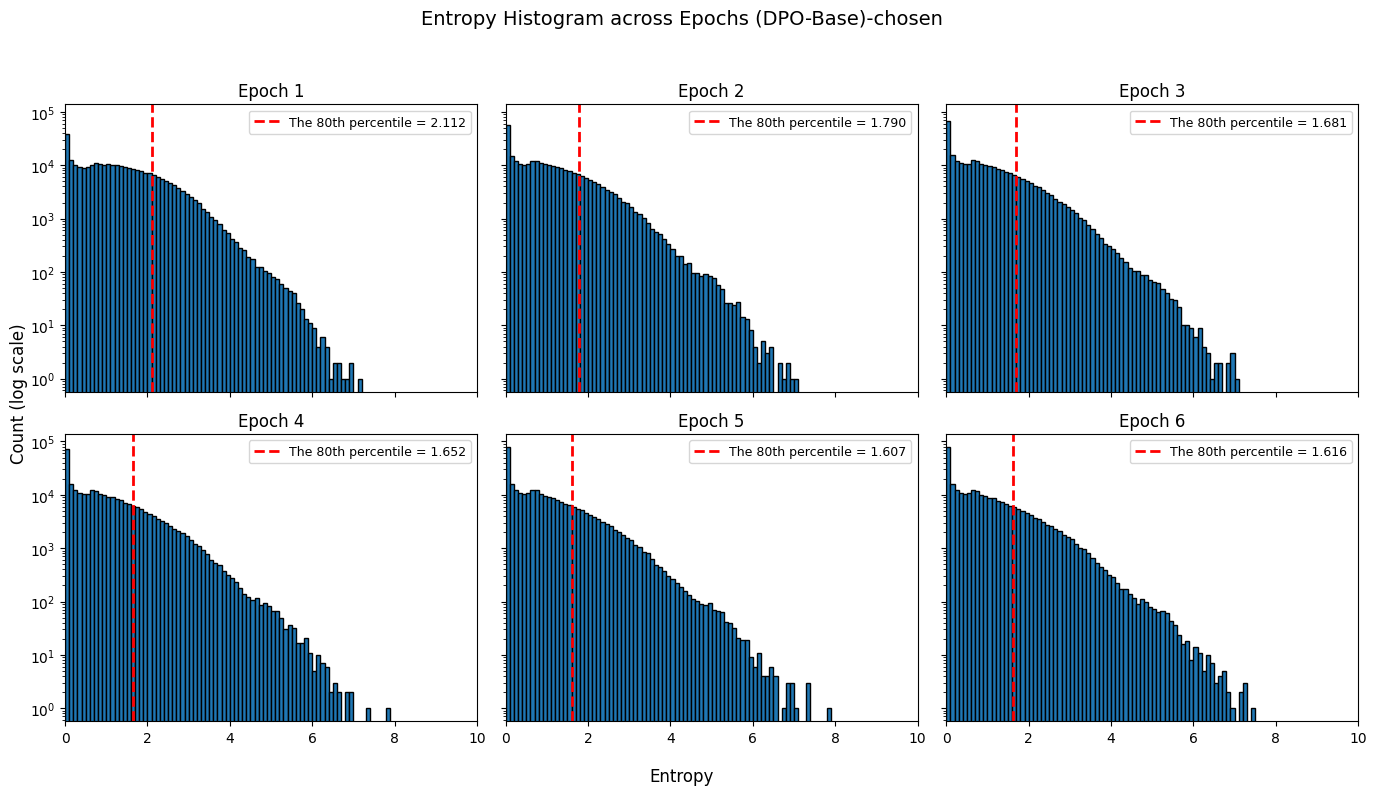

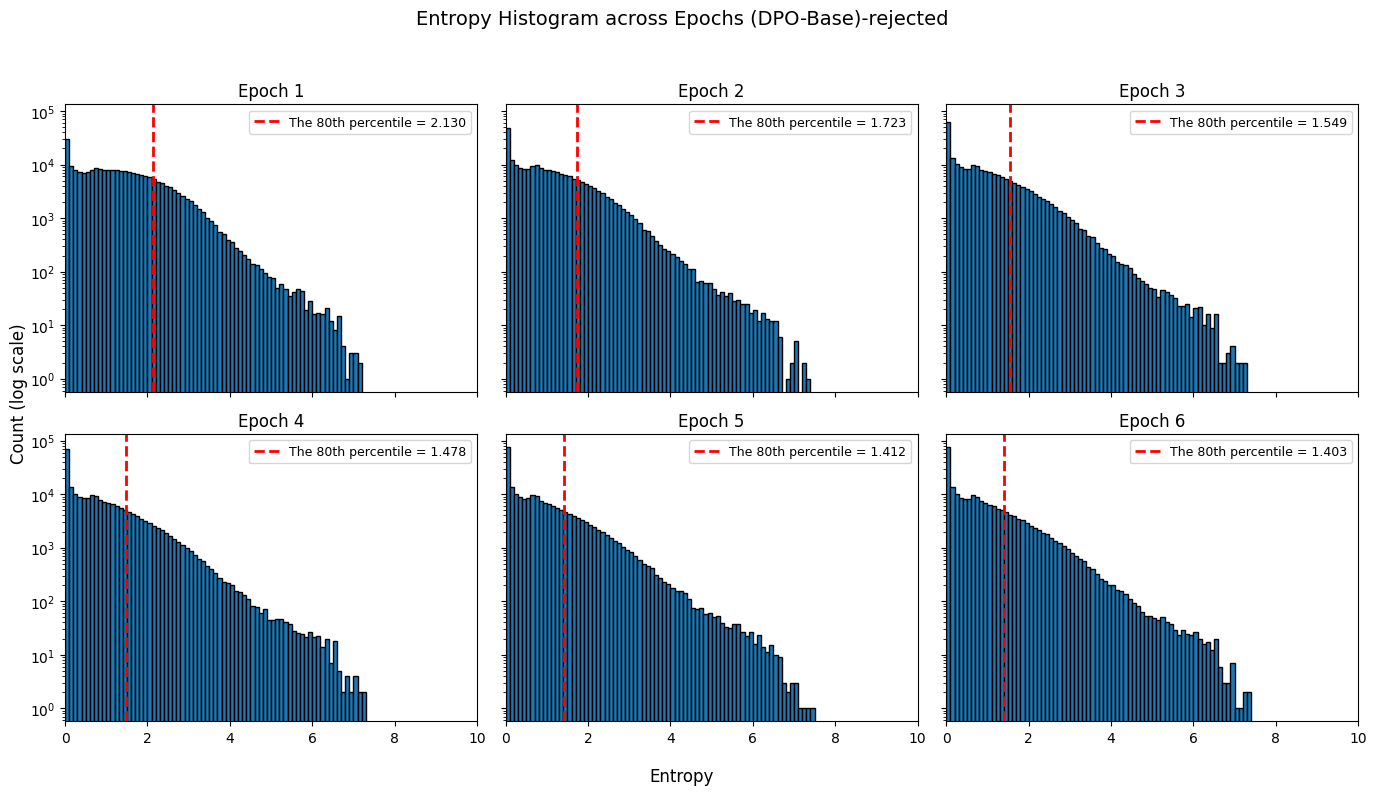

In [21]:
base_dir = "../src/exp_results/dpo_base_qwen18_hh_ep6_0105"
draw_graph(base_dir,'chosen')
draw_graph(base_dir,'rejected')

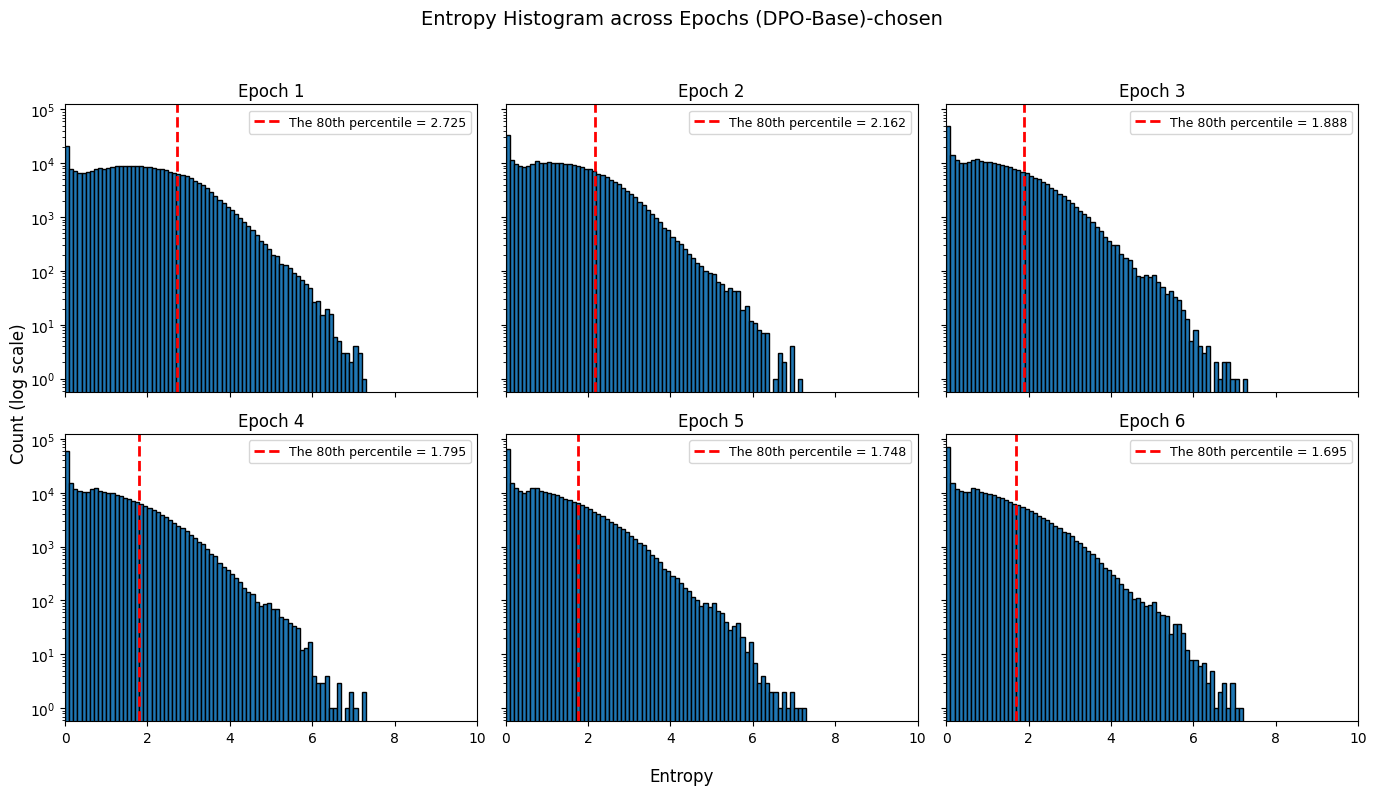

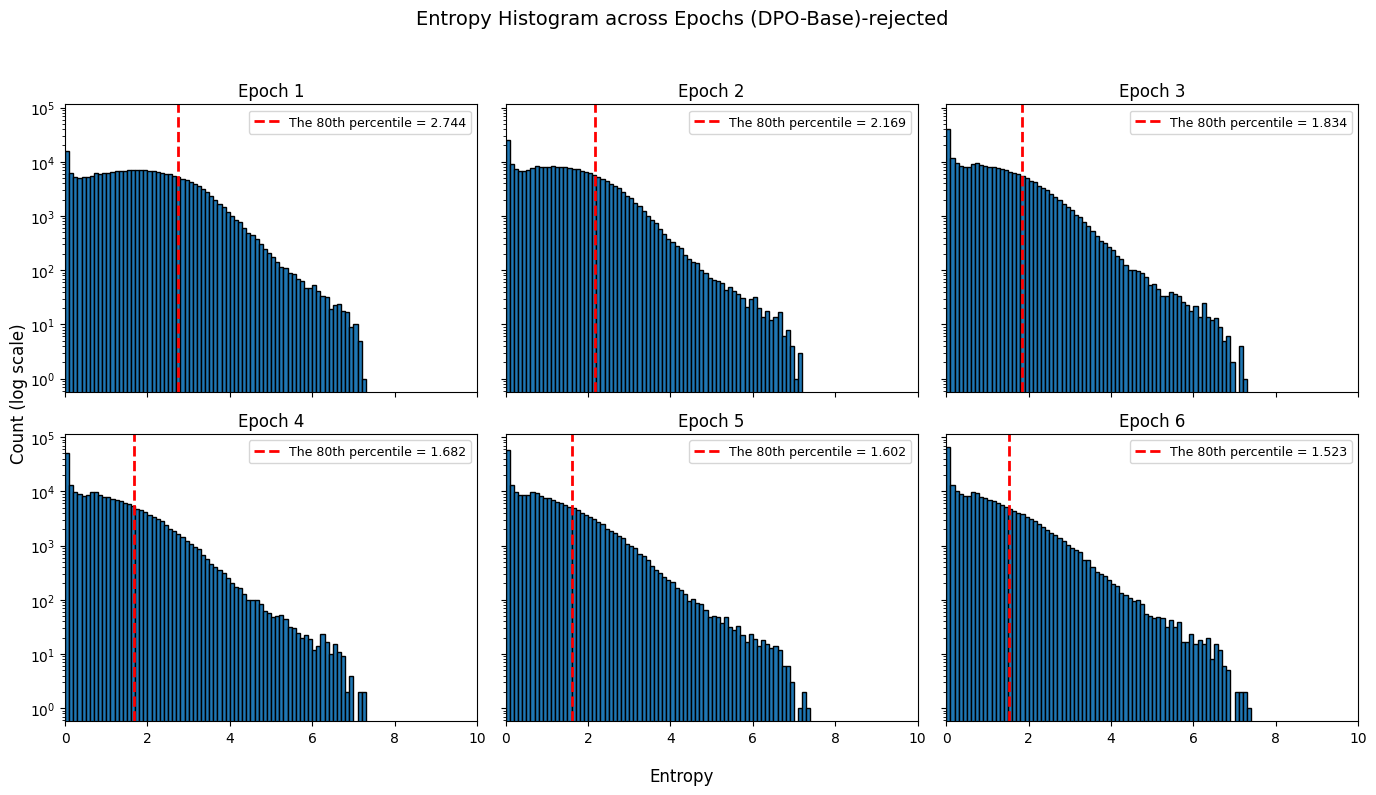

In [23]:
base_dir = "../src/exp_results/dpo_extend_qwen18_hh_ep6_0105"
draw_graph(base_dir,'chosen')
draw_graph(base_dir,'rejected')

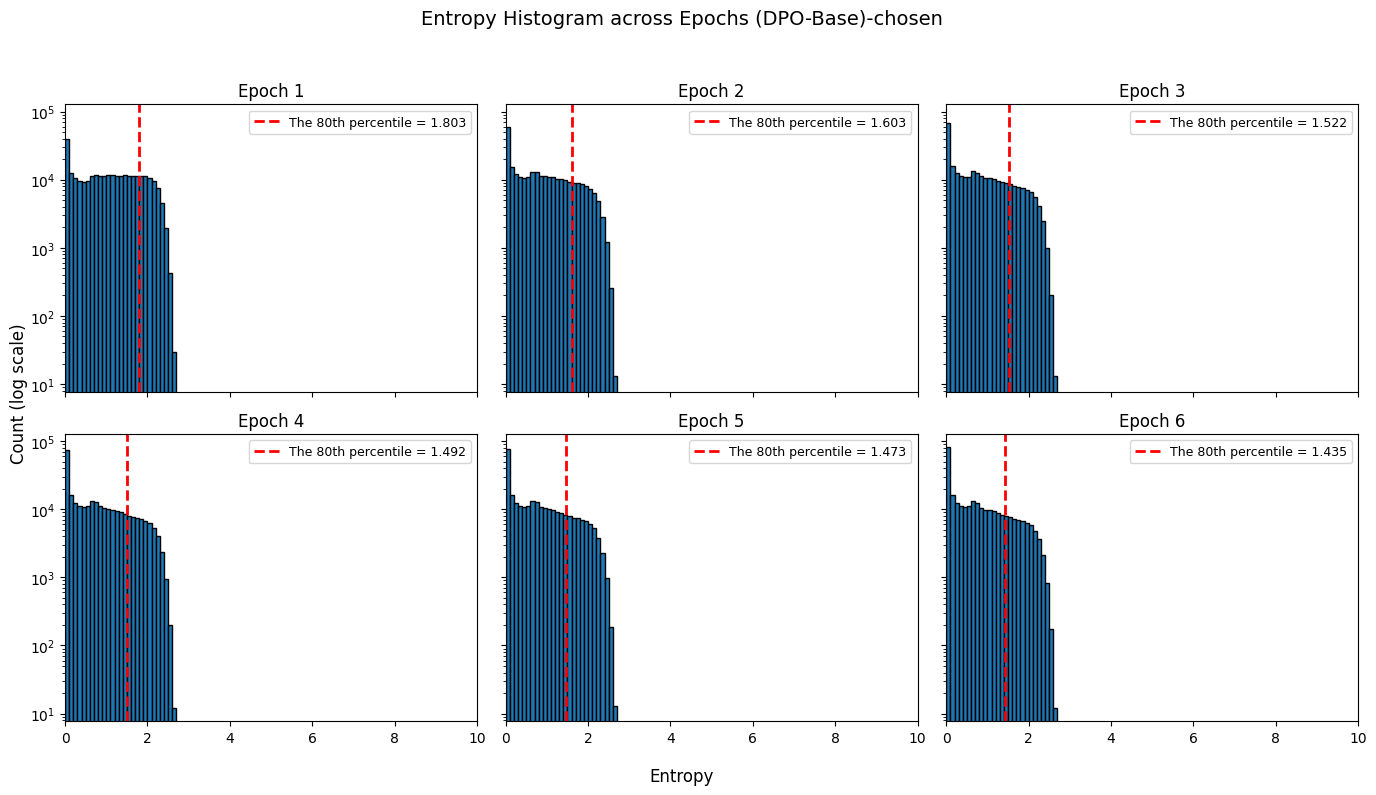

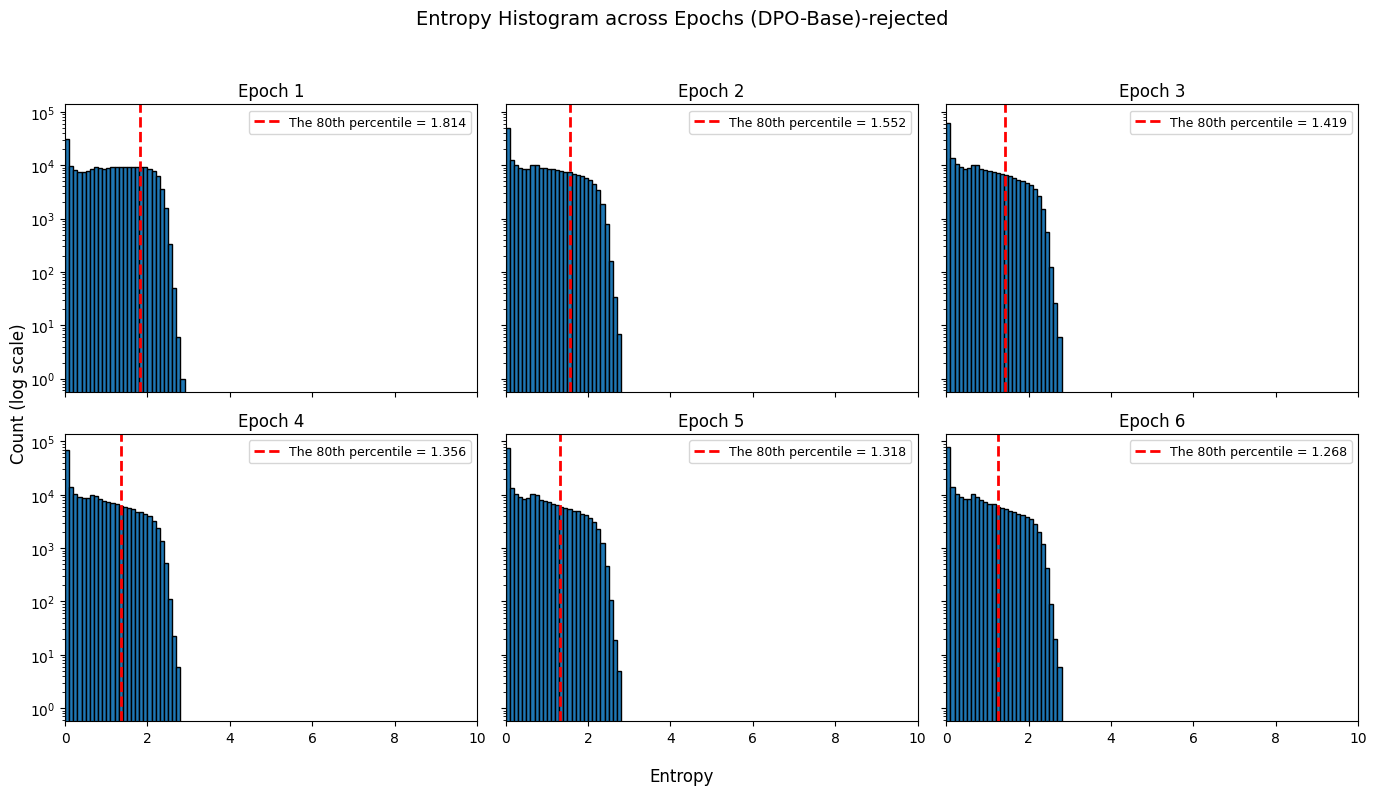

In [24]:
base_dir = "../src/exp_results/dpo_base_qwen18_hh_ep6_0105_top20entropy"
draw_graph(base_dir,'chosen')
draw_graph(base_dir,'rejected')

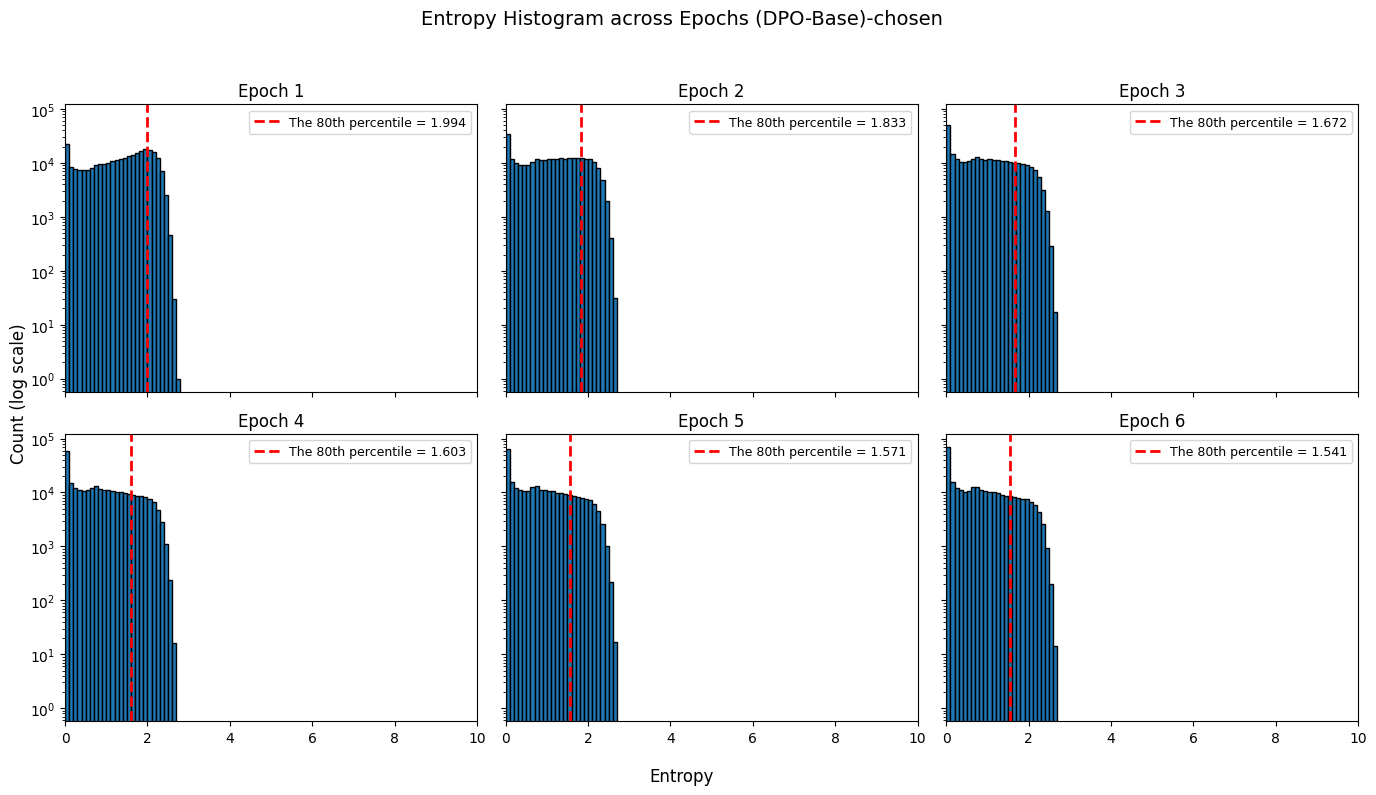

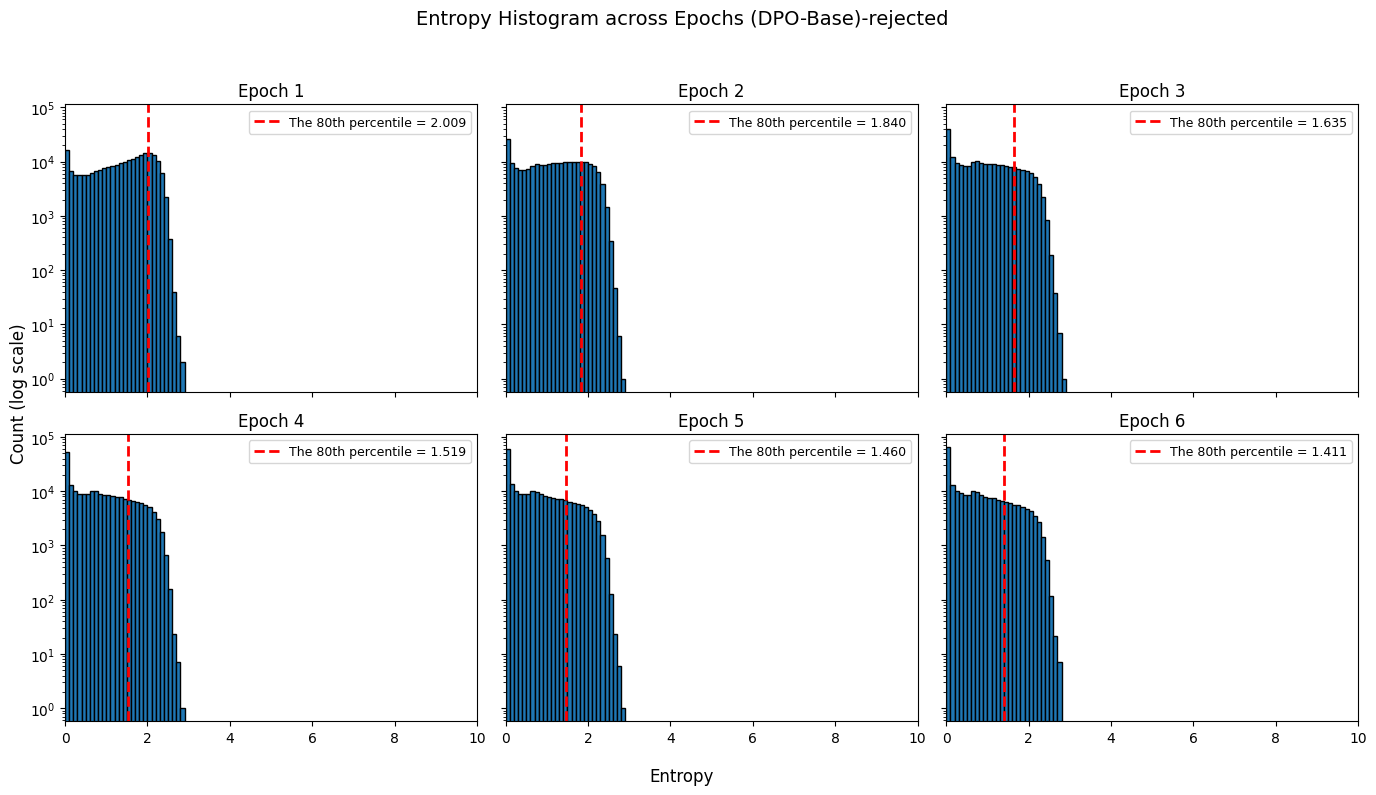

In [25]:
base_dir = "../src/exp_results/dpo_extend_qwen18_hh_ep6_0105_top20entropy"
draw_graph(base_dir,'chosen')
draw_graph(base_dir,'rejected')

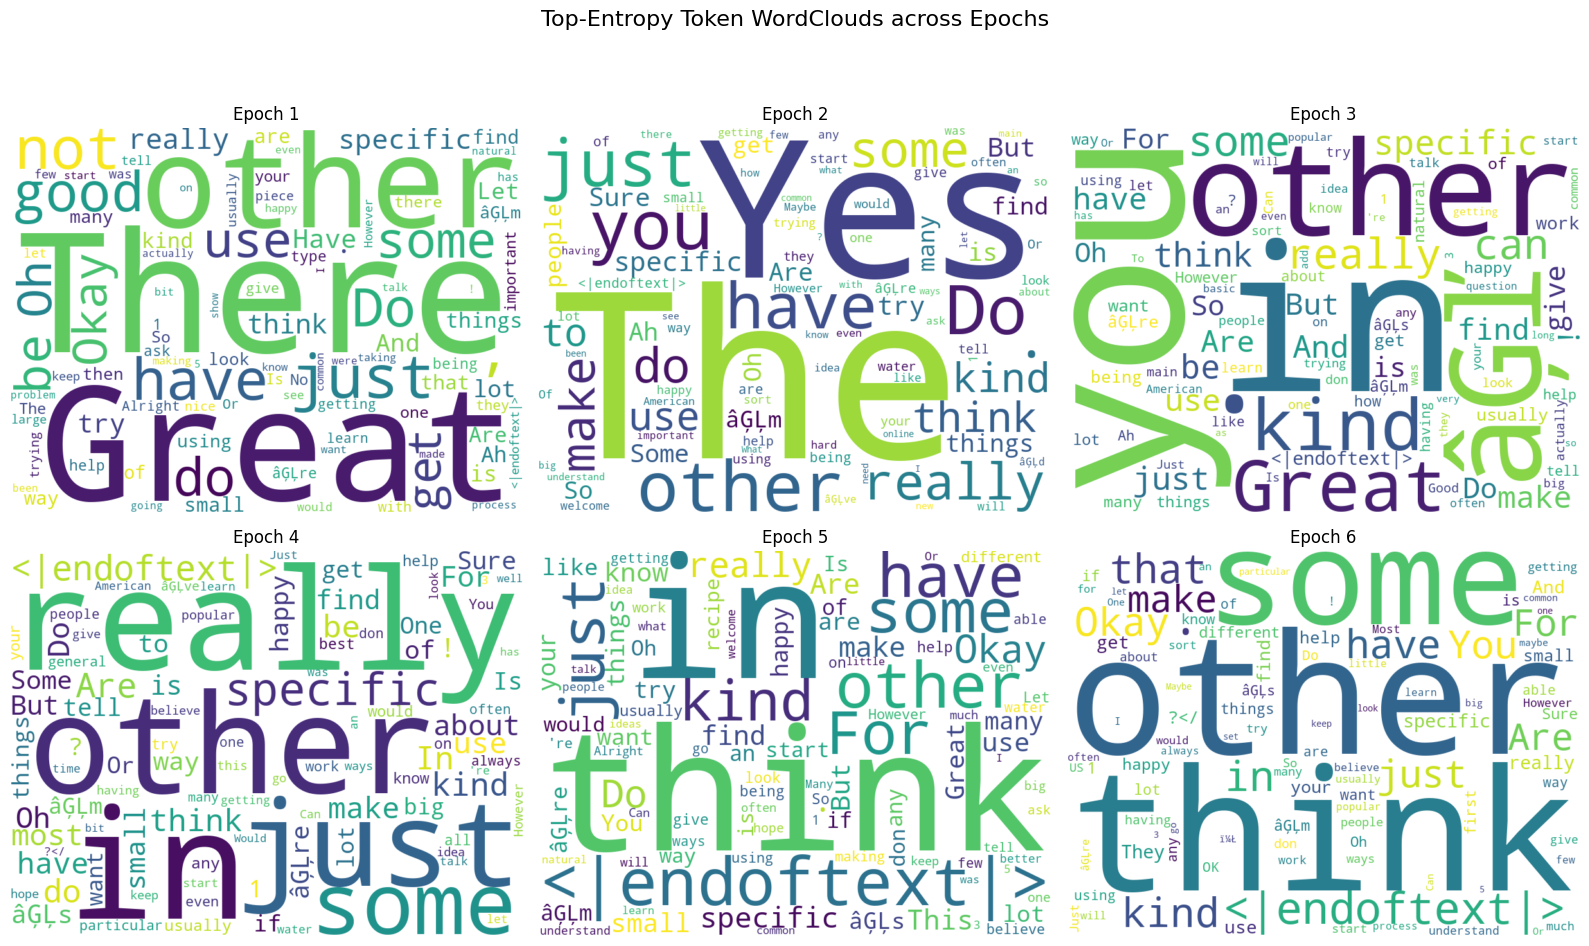

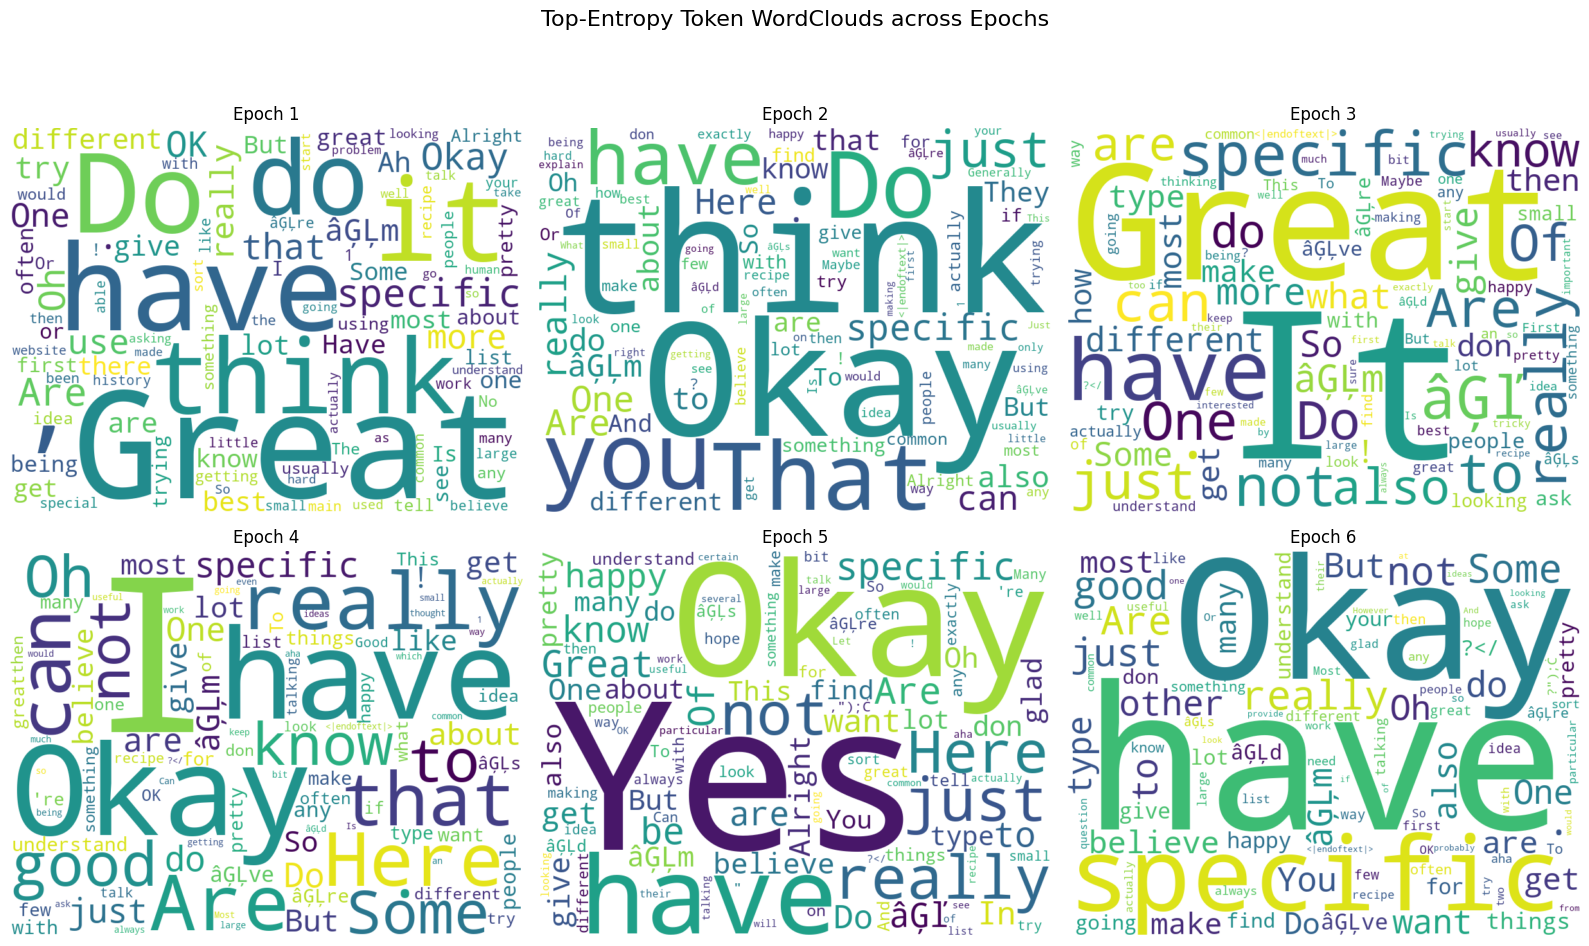

In [22]:
base_dir = "../src/exp_results/dpo_base_qwen18_hh_ep6_0105"
draw_forking_toekn_wordcloud(base_dir,'chosen')
draw_forking_toekn_wordcloud(base_dir,'rejected')

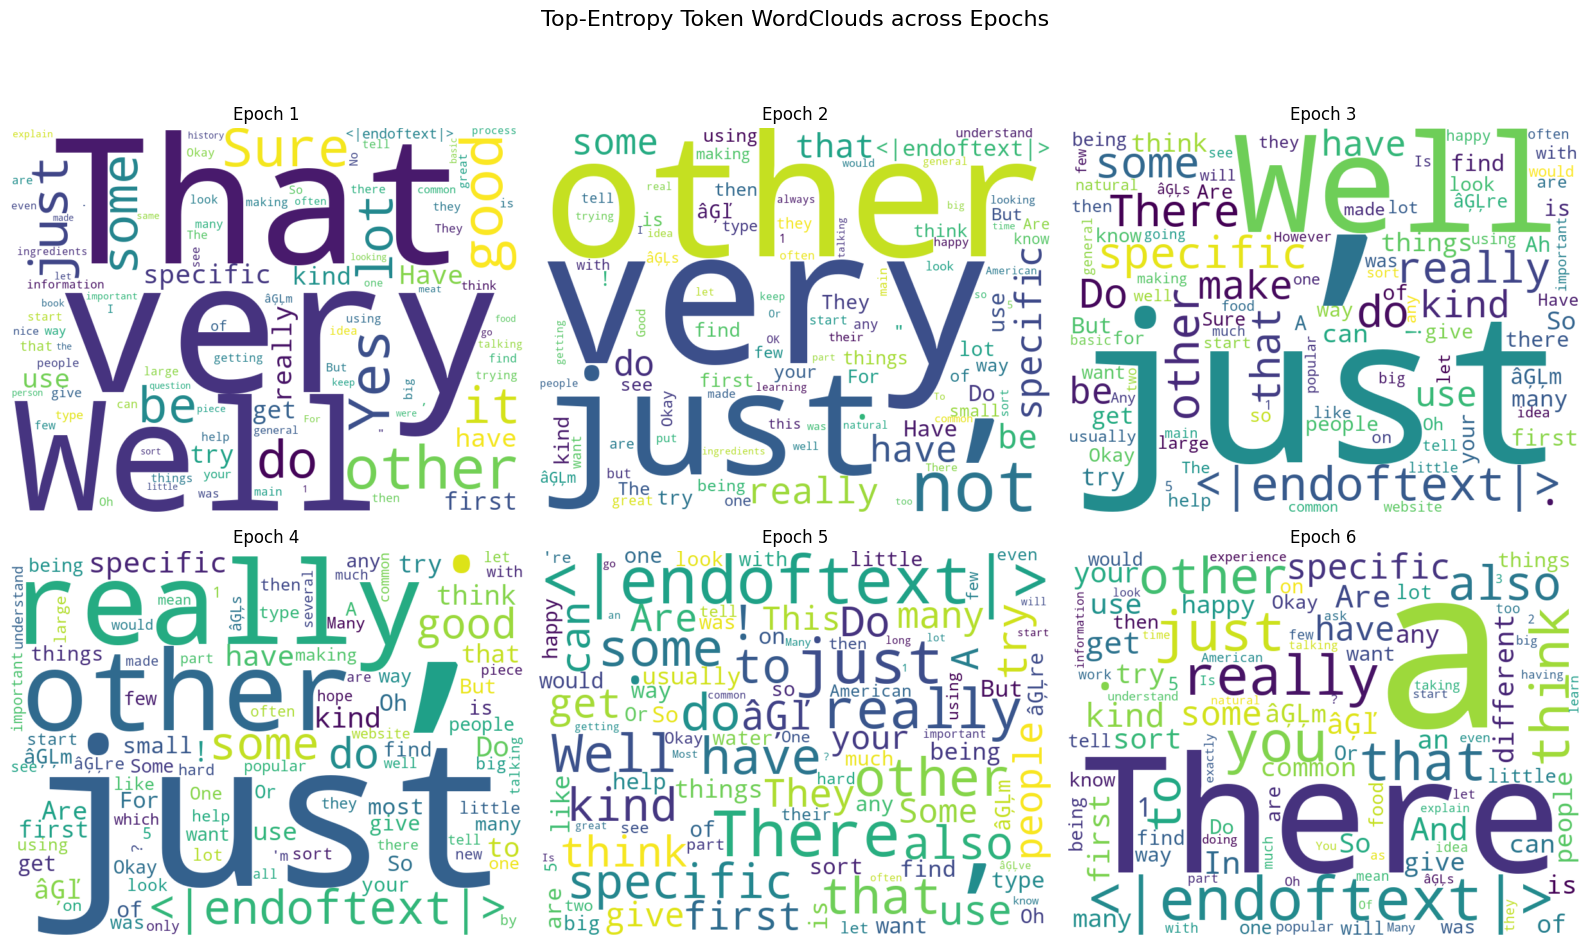

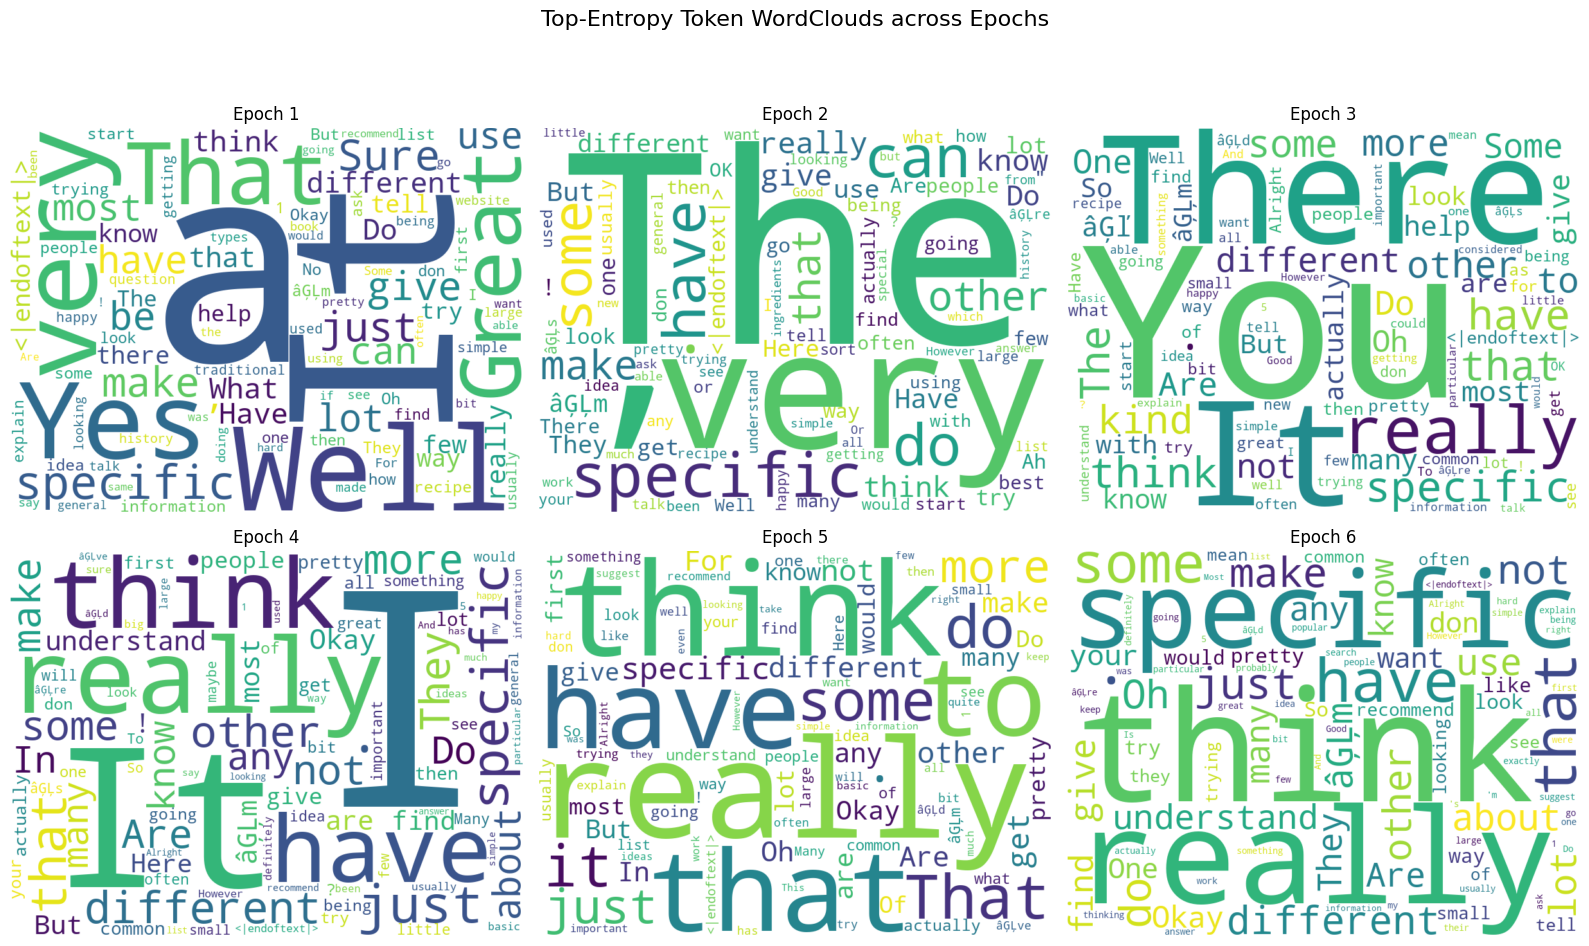

In [26]:
base_dir = "../src/exp_results/dpo_extend_qwen18_hh_ep6_0105"
draw_forking_toekn_wordcloud(base_dir,'chosen')
draw_forking_toekn_wordcloud(base_dir,'rejected')